In [2]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

from utils.Flow import analysis_folder as data_folder
from utils.WeightedCheckUtil import *
import os

# Load and show statistics

In [3]:
# test_df = pd.read_pickle(os.path.join(data_folder, 'october_net_results.pk1'))
# test_df[test_df['name'] == 'word_adjacency/spanish']

In [4]:
# display(len(test_df))
# test_df[test_df.duplicated(subset='name', keep=False)]

In [5]:
result_df = pd.concat(
    [
        pd.read_pickle(os.path.join(data_folder, 'feb26_net_results.pk1')),
        pd.read_pickle(os.path.join(data_folder, 'cpin_6_net_results.pk1')),
        pd.read_pickle(os.path.join(data_folder, 'august_20_net_results.pk1')),
        pd.read_pickle(os.path.join(data_folder, 'october_net_results.pk1'))
    ],
    ignore_index=True
)

result_df['hcs_std'] = result_df['hcs_std'].astype(float)
result_df['hcs_mean'] = result_df['hcs_mean'].astype(float)

In [6]:
display(result_df)

,name,is_mst,modularity,small_world,hcs_std,hcs_mean,assortativity,variance,fit_pl,fit_exp,wmse_pl,wmse_exp,pl_ex_ratio
0,academia_edu,False,0.664779,{'clustering_coefficient': 0.02348338660995328...,12.692582,13.093086,0.003483,0.000134,-4.653355,-0.409604,0.017371,0.027340,0.635387
1,amazon_copurchases/302,False,0.908959,{'clustering_coefficient': 0.23608271612383297...,1.482731,1.610312,-0.015383,0.000353,-3.787981,-0.190863,0.012178,0.029859,0.407838
2,anybeat,False,0.444038,{'clustering_coefficient': 0.02167593887719385...,19.526882,19.801248,-0.008030,0.000410,-4.232197,-0.757231,0.008682,0.000371,23.425625
3,arxiv_authors/CondMat,False,0.734734,{'clustering_coefficient': 0.26182397612958924...,7.804124,7.818801,0.059867,0.000927,-3.636386,-0.352497,0.012195,0.007532,1.619095
4,arxiv_citation/HepPh,False,0.735512,{'clustering_coefficient': 0.14565588394974768...,14.076138,19.964060,0.003354,0.000172,-3.858703,-0.435529,0.007565,0.011871,0.637265
...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,dblp_simplices/full-proj,False,0.773804,{'clustering_coefficient': 0.16523317403324927...,20.754931,14.496415,0.061228,0.000093,-5.072689,-0.446466,0.045055,0.004152,10.852430
116,dblp_simplices/full-proj,True,0.995680,"{'clustering_coefficient': 0.0, 'edge_num': 16...",0.645885,0.812183,-0.133249,0.000241,-2.594097,-0.108123,0.005572,0.008609,0.647216
117,bitcoin,False,0.713615,{'clustering_coefficient': 7.685084806402829e-...,27.587524,14.940326,0.081568,0.000084,-2.087630,-0.073670,0.003422,0.061285,0.055843
118,bitcoin,True,0.742998,"{'clustering_coefficient': 0.0, 'edge_num': 62...",0.807471,0.688339,0.053585,0.000171,-1.736114,-0.071283,0.001360,0.003820,0.356054


In [7]:
df = result_df.copy()
df = df[~df['is_mst']]
len(df)

91

In [8]:
mst_df = result_df.copy()
mst_df = mst_df[mst_df['is_mst']]
len(mst_df)

29

In [9]:
feature_cols = ['CC_norm', 'L_norm', 'modularity', 'hcs_std', 'assortativity']
small_world_features = ['CC_norm', 'L_norm']
community_features = ['modularity']
structure_features = ['hcs_std', 'assortativity']
target_col_clas = 'is_fractal'

### Properties preparation

In [10]:
df['CC_norm'] = df['small_world'].str.get('clustering_coefficient_normalized')
df['L_norm'] = df['small_world'].str.get('l_normalized')
df['V'] = df['small_world'].str.get('vertice_num')
df['E'] = df['small_world'].str.get('edge_num')

mst_df['CC_norm'] = mst_df['small_world'].str.get('clustering_coefficient_normalized')
mst_df['L_norm'] = mst_df['small_world'].str.get('l_normalized')
mst_df['V'] = mst_df['small_world'].str.get('vertice_num')
mst_df['E'] = mst_df['small_world'].str.get('edge_num')

## Statistics

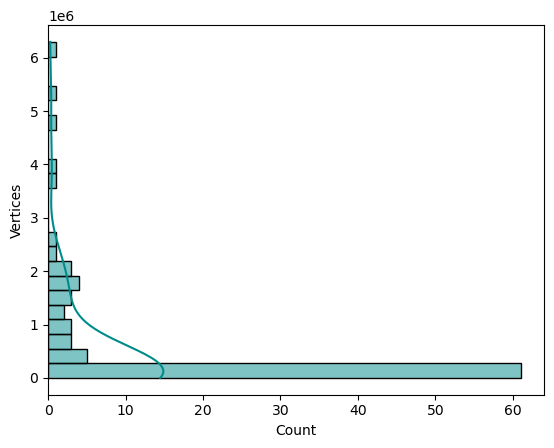

In [11]:
sns.histplot(data=df, y='V', kde=True, color='darkcyan')

# plt.title('Distribution of the Vertices')
# plt.xscale('log')
plt.ylabel('Vertices')
plt.show()

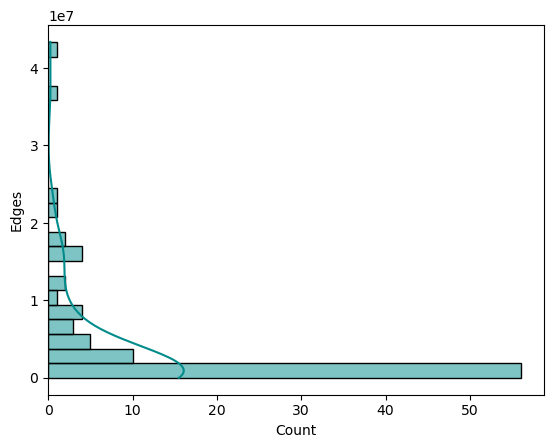

In [12]:
sns.histplot(data=df, y='E', kde=True, color='darkcyan')

# plt.title('Distribution of the Edges')
# plt.xscale('log')
plt.ylabel("Edges")
plt.show()

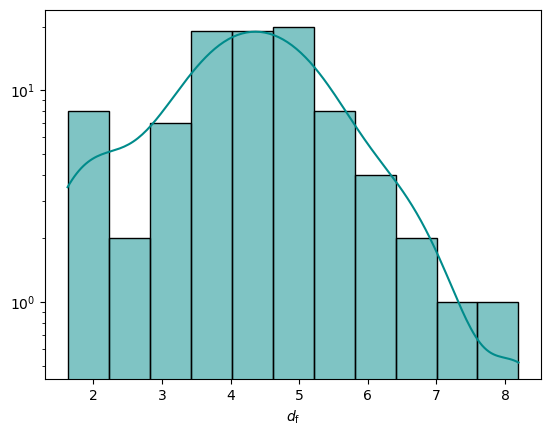

In [13]:
sns.histplot(data=df.assign(fit_pl=df['fit_pl'] * -1), x='fit_pl', kde=True, color='darkcyan')

# plt.title('Distribution of the Fractality dimension')
plt.yscale('log')
plt.ylabel('')
plt.xlabel('$d_\mathrm{f}$')
plt.show()

In [14]:
df[df['pl_ex_ratio']>100]

,name,is_mst,modularity,small_world,hcs_std,hcs_mean,assortativity,variance,fit_pl,fit_exp,wmse_pl,wmse_exp,pl_ex_ratio,CC_norm,L_norm,V,E
47,twitter,False,0.687918,{'clustering_coefficient': 0.00061262722552796...,11.119289,14.971752,-0.058327,0.000116,-4.82384,-0.862904,0.016375,0.000024,669.629611,79.465126,0.45132,465017,833540


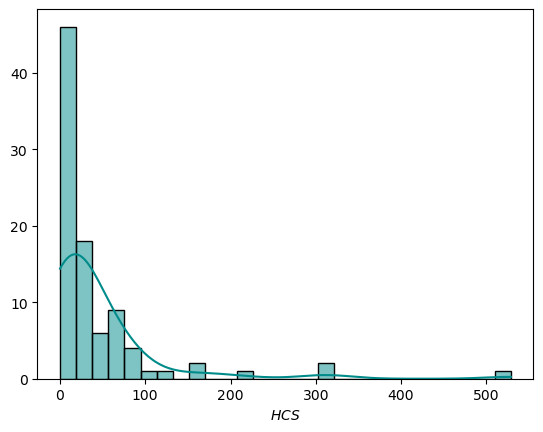

In [15]:
sns.histplot(data=df, x='hcs_std', kde=True, color='darkcyan')

# plt.title('Distribution of the $HCS$')
# plt.yscale('log')
plt.ylabel('')
plt.xlabel('$HCS$')
plt.show()

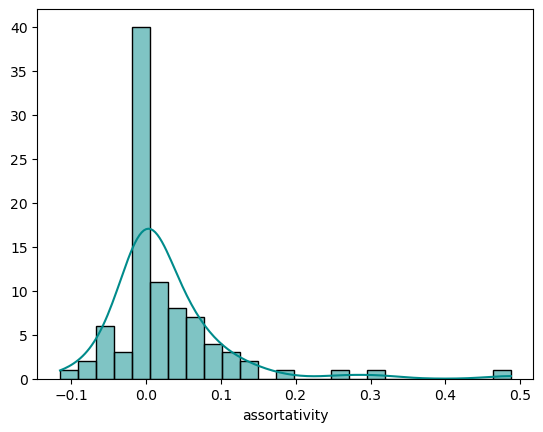

In [16]:
sns.histplot(data=df, x='assortativity', kde=True, color='darkcyan')

# plt.title('Distribution of the assortativity')
# plt.yscale('log')
plt.ylabel('')
plt.xlabel('assortativity')
plt.show()

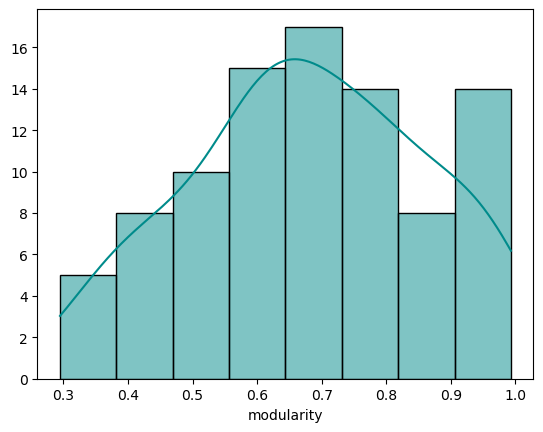

In [17]:
sns.histplot(data=df, x='modularity', kde=True, color='darkcyan')

# plt.title('Distribution of the Modularity score')
# plt.yscale('log')
plt.ylabel('')
plt.xlabel('modularity')
plt.show()

In [18]:
df[df['assortativity']<-0.1]

,name,is_mst,modularity,small_world,hcs_std,hcs_mean,assortativity,variance,fit_pl,fit_exp,wmse_pl,wmse_exp,pl_ex_ratio,CC_norm,L_norm,V,E
99,twitter_higgs/reply,False,0.912682,{'clustering_coefficient': 0.00040007344343406...,0.368421,1.101167,-0.114758,0.002394,-2.852162,-0.157934,0.006753,0.011181,0.603986,2.334594,0.611336,12839,14123


In [19]:
ns_dataset_weighting = pd.read_csv('network_info_community.csv')
ns_dataset_weighting.head()

,Unnamed: 0,average_degree,degree_assortativity,degree_std_dev,diameter,edge_properties,edge_reciprocity,global_clustering,hashimoto_radius,is_bipartite,...,mixing_time,num_edges,num_vertices,transition_gap,vertex_properties,name,tags,is_weighted,ds_name,community_label
0,85,6.984413,-0.016419,46.241795,16,[],0.537030,0.036263,109.991372,False,...,78.338610,1398063,200169,0.987316,"[['name', 'int32_t'], ['_pos', 'vector<double>']]",academia_edu,"['Social', 'Online', 'Unweighted']",Unweighted,academia_edu,Social
1,88,4.711275,-0.002543,5.919191,38,[],0.542702,0.310868,17.803235,False,...,3944.332763,1234877,262111,0.999747,"[['_pos', 'vector<double>']]",amazon_copurchases/302,"['Economic', 'Commerce', 'Unweighted']",Unweighted,amazon_copurchases,Economic
2,89,7.986584,-0.017233,15.834028,20,[],0.531534,0.248231,35.027683,False,...,895.794973,3200440,400727,0.998884,"[['_pos', 'vector<double>']]",amazon_copurchases/312,"['Economic', 'Commerce', 'Unweighted']",Unweighted,amazon_copurchases,Economic
3,90,8.182666,-0.013417,16.297625,22,[],0.546580,0.251219,40.356201,False,...,1805.088792,3356824,410236,0.999446,"[['_pos', 'vector<double>']]",amazon_copurchases/505,"['Economic', 'Commerce', 'Unweighted']",Unweighted,amazon_copurchases,Economic
4,91,8.397220,-0.013843,16.145707,25,[],0.557350,0.256012,40.310977,False,...,3656.500797,3387388,403394,0.999727,"[['_pos', 'vector<double>']]",amazon_copurchases/601,"['Economic', 'Commerce', 'Unweighted']",Unweighted,amazon_copurchases,Economic


In [20]:
df_community_merged = pd.merge(
    df,
    ns_dataset_weighting[['name', 'community_label', 'is_weighted']],
    on='name',
    how='left'
)

display(df_community_merged.head())

print(df_community_merged['community_label'].isna().sum())
print(df_community_merged['is_weighted'].isna().sum())

,name,is_mst,modularity,small_world,hcs_std,hcs_mean,assortativity,variance,fit_pl,fit_exp,wmse_pl,wmse_exp,pl_ex_ratio,CC_norm,L_norm,V,E,community_label,is_weighted
0,academia_edu,False,0.664779,{'clustering_coefficient': 0.02348338660995328...,12.692582,13.093086,0.003483,0.000134,-4.653355,-0.409604,0.017371,0.027340,0.635387,459.926027,0.872594,200167,1022882,Social,Unweighted
1,amazon_copurchases/302,False,0.908959,{'clustering_coefficient': 0.23608271612383297...,1.482731,1.610312,-0.015383,0.000353,-3.787981,-0.190863,0.012178,0.029859,0.407838,9012.824358,1.318159,262111,899792,Economic,Unweighted
2,anybeat,False,0.444038,{'clustering_coefficient': 0.02167593887719385...,19.526882,19.801248,-0.008030,0.000410,-4.232197,-0.757231,0.008682,0.000371,23.425625,35.268485,0.657314,12645,49132,Social,Unweighted
3,arxiv_authors/CondMat,False,0.734734,{'clustering_coefficient': 0.26182397612958924...,7.804124,7.818801,0.059867,0.000927,-3.636386,-0.352497,0.012195,0.007532,1.619095,654.053167,1.097560,21363,91342,Social,Unweighted
4,arxiv_citation/HepPh,False,0.735512,{'clustering_coefficient': 0.14565588394974768...,14.076138,19.964060,0.003354,0.000172,-3.858703,-0.435529,0.007565,0.011871,0.637265,204.796683,1.206269,34401,420828,Academic,Unweighted


0
0


In [21]:
def plot_tag_pie_chart(
    column: pd.Series,
    figAx: tuple,
    title='Distribution',
    pct='%1.1f%%',
    label_filter=lambda pct: pct > 1,
    colors=None
):
    fig, ax = figAx
    
    value_counts = column.value_counts()

    percentages = value_counts / value_counts.sum() * 100

    # Create the pie chart
    _, texts, _ = ax.pie(value_counts.values.tolist(), labels=value_counts.index.tolist(
    ), autopct=pct, startangle=90, pctdistance=0.8, colors=colors)

    # Filters labes based on provided filter function
    if label_filter != None:
        for i, pct in enumerate(percentages):
            if label_filter(pct):
                texts[i].set_visible(True)
            else:
                texts[i].set_visible(False)

    ax.legend(labels=value_counts.index.tolist(),
              loc='best', bbox_to_anchor=(1, 0.5))
    fig.suptitle(title)
    plt.show()

In [22]:
def create_colors(length, palette_name='viridis'):
    cmap = plt.get_cmap(palette_name)
    return cmap(np.linspace(0,10), length)

In [23]:
df_community_merged['community_label'].value_counts()

community_label
Social           49
Academic         22
Technological     8
Biological        5
Transport         4
Economic          3
Name: count, dtype: int64

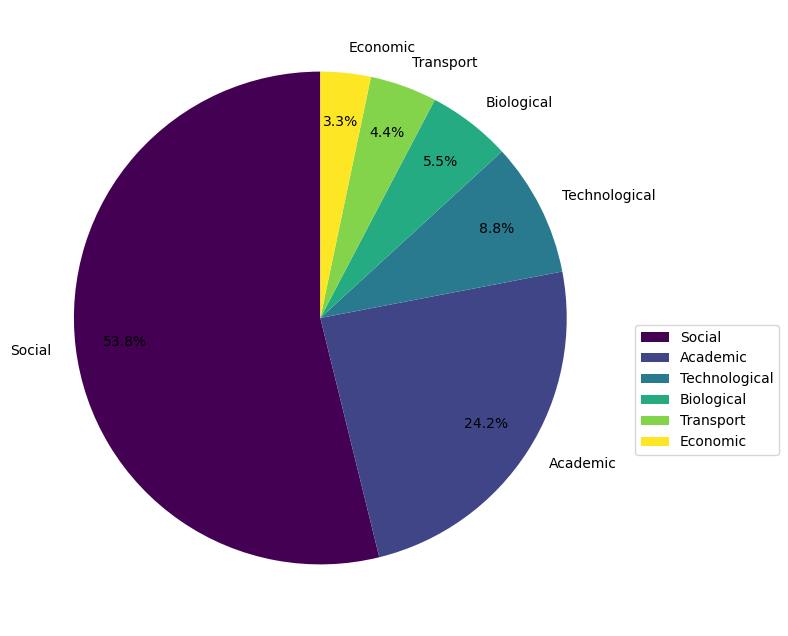

In [24]:
plot_tag_pie_chart(
    column=df_community_merged['community_label'],
    figAx=plt.subplots(figsize=(8, 8)),
    # title='Community label distribution',
    title='',
    colors=create_colors(len(df_community_merged['community_label'].value_counts()), 'viridis')
)

In [25]:
def barplot_with_percent(df, column_name, color_palette, title, xlabel, ylabel, horizontal = True, order = None):
    if horizontal:
        ax = sns.countplot(
            data=df, 
            y=column_name, 
            hue=column_name,
            palette=color_palette,
            order=order,
            legend=False 
        )
    else:
        ax = sns.countplot(
            data=df, 
            x=column_name, 
            hue=column_name,
            palette=color_palette,
            order=order,
            legend=False 
        )

    for container in ax.containers:
        percentages = [f'{100 * v / len(df):.1f}%' if v > 0 else '' for v in container.datavalues]
        
        ax.bar_label(container, labels=percentages, padding=3)

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    if(horizontal):
        plt.xlim(0, ax.get_xlim()[1] * 1.15)
    else: 
        plt.ylim(0, ax.get_ylim()[1] * 1.15)

    plt.show()

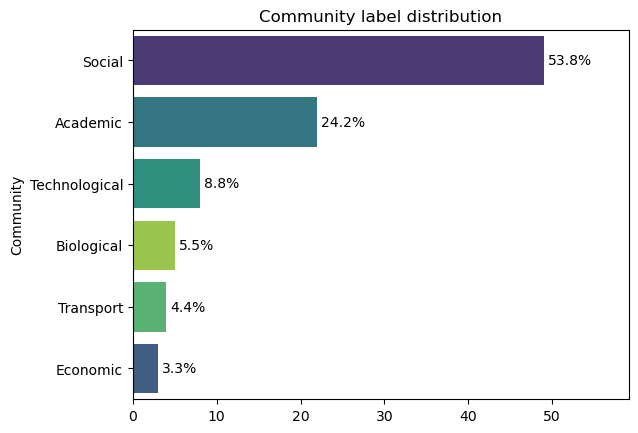

In [26]:
barplot_with_percent(
    df_community_merged,
    'community_label',
    'viridis',
    'Community label distribution',
    '',
    'Community',
    order=df_community_merged['community_label'].value_counts().index
)

In [27]:
mst_community_merged = pd.merge(
    mst_df,
    ns_dataset_weighting[['name', 'community_label', 'is_weighted']],
    on='name',
    how='left'
)

display(mst_community_merged.head())

print(mst_community_merged['community_label'].isna().sum())
print(mst_community_merged['is_weighted'].isna().sum())

,name,is_mst,modularity,small_world,hcs_std,hcs_mean,assortativity,variance,fit_pl,fit_exp,wmse_pl,wmse_exp,pl_ex_ratio,CC_norm,L_norm,V,E,community_label,is_weighted
0,word_assoc,True,0.980147,"{'clustering_coefficient': 0.0, 'edge_num': 23...",0.547844,0.820472,-0.162409,0.002092,-2.129801,-0.085667,0.001365,0.011689,0.116761,0.0,2.870252,23132,23131,Academic,Unweighted
1,human_brains/BNU1_0025915_2_DTI_DS16784,True,0.955167,"{'clustering_coefficient': 0.0, 'edge_num': 12...",0.393113,0.531697,-0.086271,0.003576,-1.667700,-0.067258,0.000837,0.004882,0.171438,0.0,3.848272,12454,12453,Biological,Weighted
2,us_agencies/aggregate,True,0.930427,"{'clustering_coefficient': 0.0, 'edge_num': 42...",0.294574,0.690014,-0.164688,0.001384,-2.383056,-0.095299,0.001942,0.016002,0.121362,0.0,1.565373,42800,42799,Economic,Weighted
3,physics_collab/arXiv,True,0.969574,"{'clustering_coefficient': 0.0, 'edge_num': 87...",0.519108,0.668478,-0.100285,0.003687,-2.215986,-0.092242,0.003547,0.005528,0.641711,0.0,1.812464,8798,8797,Social,Weighted
4,topology,True,0.962345,"{'clustering_coefficient': 0.0, 'edge_num': 34...",0.883871,0.959016,-0.247547,0.001249,-3.387849,-0.301432,0.004096,0.019584,0.209151,0.0,0.495625,34761,34760,Technological,Unweighted


0
0


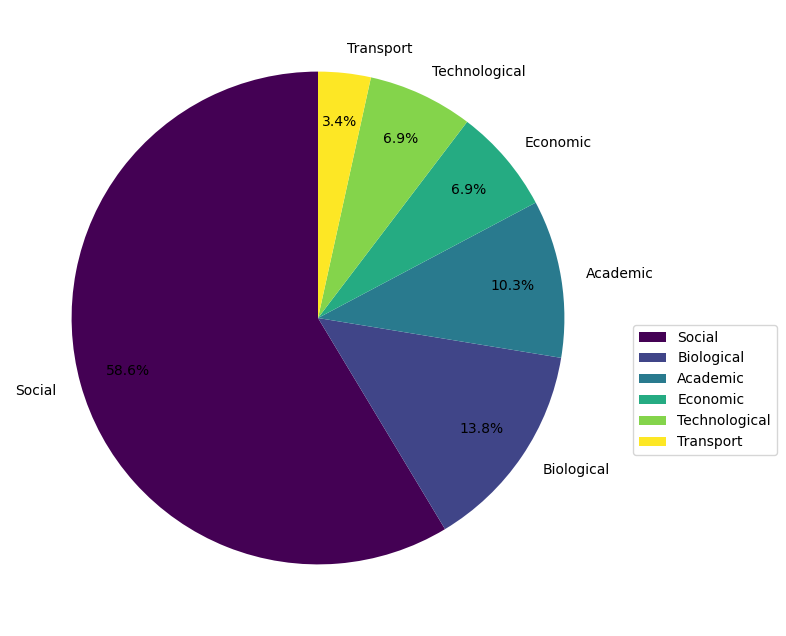

In [28]:
plot_tag_pie_chart(
    column=mst_community_merged['community_label'],
    figAx=plt.subplots(figsize=(8, 8)),
    # title='Community label distribution across MSTs',
    title='',
    colors=create_colors(len(mst_community_merged['community_label'].value_counts()), 'viridis')
)

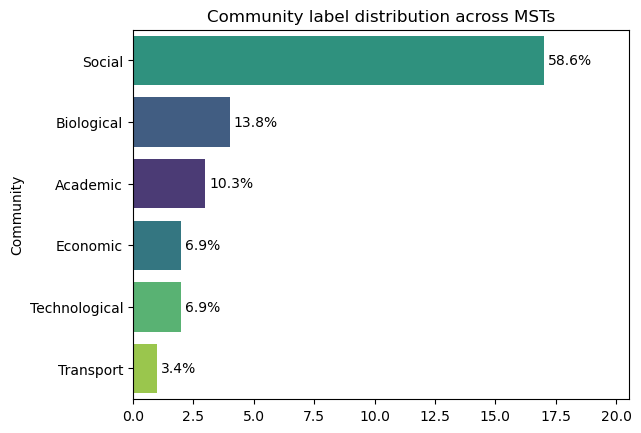

In [29]:
barplot_with_percent(
    mst_community_merged, 
    'community_label',
    'viridis',
    'Community label distribution across MSTs',
    '',
    'Community',
    order=mst_community_merged['community_label'].value_counts().index
)

# Decision Trees

In [30]:
def add_is_fractal(to, using_dimention=-3):
    to.loc[:, 'is_fractal'] = (to['pl_ex_ratio'] < 1) & (to['fit_pl'] >= using_dimention)

In [31]:
add_is_fractal(to=df, using_dimention=-4)
display(df[df['is_fractal']])
display(len(df[df['is_fractal']]))

,name,is_mst,modularity,small_world,hcs_std,hcs_mean,assortativity,variance,fit_pl,fit_exp,wmse_pl,wmse_exp,pl_ex_ratio,CC_norm,L_norm,V,E,is_fractal
1,amazon_copurchases/302,False,0.908959,{'clustering_coefficient': 0.23608271612383297...,1.482731,1.610312,-0.015383,0.000353,-3.787981,-0.190863,0.012178,0.029859,0.407838,9012.824358,1.318159,262111,899792,True
4,arxiv_citation/HepPh,False,0.735512,{'clustering_coefficient': 0.14565588394974768...,14.076138,19.964060,0.003354,0.000172,-3.858703,-0.435529,0.007565,0.011871,0.637265,204.796683,1.206269,34401,420828,True
7,berkstan_web,False,0.938770,{'clustering_coefficient': 0.00691792331273844...,10.416667,36.611556,0.059905,0.000100,-2.041615,-0.079020,0.000056,0.023066,0.002442,225.314521,1.513236,654782,6581871,True
8,caida_as/20071112,False,0.684168,{'clustering_coefficient': 0.00692211268037172...,11.500000,6.276613,-0.054843,0.000544,-3.001261,-0.220250,0.005025,0.093900,0.053519,45.593476,0.521918,26389,52861,True
9,chicago_road,False,0.935495,"{'clustering_coefficient': 0.0455460445865864,...",0.093023,0.000000,0.121474,0.004709,-1.897340,-0.074961,0.000733,0.010177,0.072051,185.966024,5.123853,12979,20627,True
10,citeseer,False,0.811410,{'clustering_coefficient': 0.04957699845996569...,5.931801,8.760695,0.005290,0.000121,-3.877840,-0.200198,0.013956,0.027123,0.514565,1912.467666,1.089604,365154,1728252,True
11,cora,False,0.801289,"{'clustering_coefficient': 0.1168747561740802,...",4.477961,6.035642,0.005262,0.000617,-3.436130,-0.288926,0.008750,0.012183,0.718237,351.737467,1.139792,23166,89157,True
15,ego_social/gplus_combined,False,0.476338,{'clustering_coefficient': 0.15363098036716577...,528.871517,493.534742,0.000083,0.000006,-3.768669,-0.747103,0.000318,0.006194,0.051318,72.687839,1.132995,107614,12238285,True
16,email_enron,False,0.614890,{'clustering_coefficient': 0.08512972961362862...,33.401198,25.628478,0.025350,0.000423,-3.653954,-0.404342,0.004068,0.017984,0.226215,267.282313,0.865701,33696,180811,True
17,email_eu,False,0.788840,{'clustering_coefficient': 0.00416338457203835...,23.695052,14.094711,-0.086262,0.000286,-3.582913,-0.358894,0.003561,0.025231,0.141118,308.771803,0.370274,224832,340795,True


29

In [32]:
X_clas = df[feature_cols]

X_small_world = df[small_world_features]

X_community = df[community_features]

X_structure = df[structure_features]

y_clas = df[target_col_clas]

In [33]:
dt_classifier = DecisionTreeClassifier(random_state=42, max_depth=5)
print("Training Decision Tree...")
dt_classifier.fit(X_clas, y_clas)

dt_small_world = DecisionTreeClassifier(random_state=42, max_depth=3)
print("Training small world tree..")
dt_small_world.fit(X_small_world, y_clas)

dt_community = DecisionTreeClassifier(random_state=42, max_depth=2)
print("Training community tree")
dt_community.fit(X_community, y_clas)

dt_structure = DecisionTreeClassifier(random_state=42, max_depth=3)
print("Training struture tree")
dt_structure.fit(X_structure, y_clas)


print("-" * 30)

Training Decision Tree...
Training small world tree..
Training community tree
Training struture tree
------------------------------


In [34]:
X_structure.assign(is_assort=X_structure['assortativity'] > 0).drop(columns=['assortativity'])

,hcs_std,is_assort
0,12.692582,True
1,1.482731,False
2,19.526882,False
3,7.804124,True
4,14.076138,True
...,...,...
111,107.047882,True
113,1.692529,False
115,20.754931,True
117,27.587524,True


In [35]:
dt_structure_cat = DecisionTreeClassifier(random_state=42, max_depth=3)
dt_structure_cat.fit(
    X_structure.assign(is_assort=X_structure['assortativity'] > 0).drop(columns=['assortativity']),
    y_clas
)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [36]:
def tree_plot(tree, feature_columns, figsize=(16, 8)):
    plt.figure(figsize=figsize) 
    plot_tree(
        tree, 
        feature_names=feature_columns, 
        class_names=['Not Fractal', 'Fractal'], 
        filled=True,
        rounded=True,
        fontsize=12
    )
    plt.show()

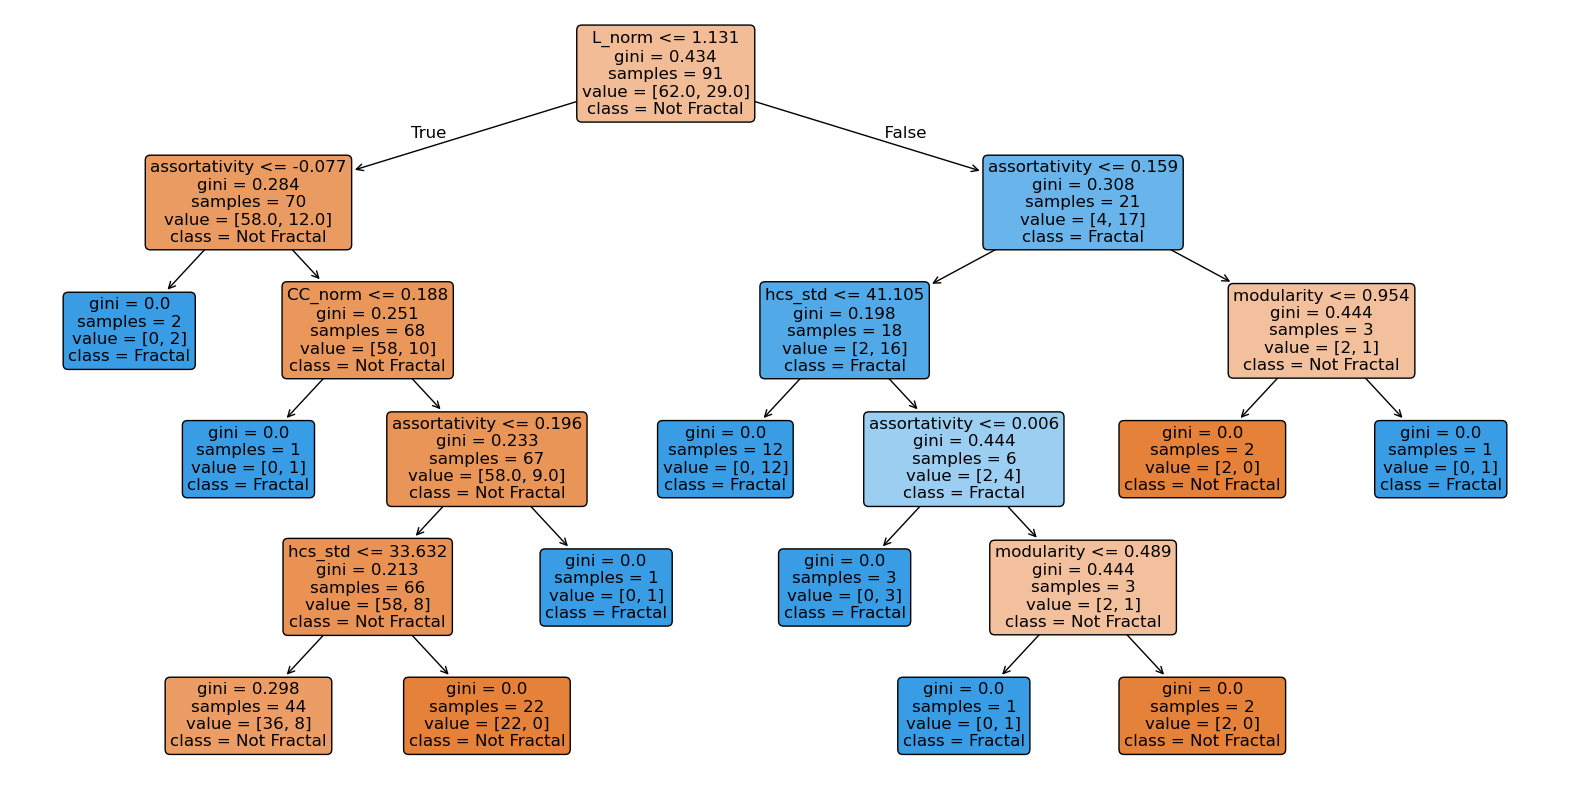

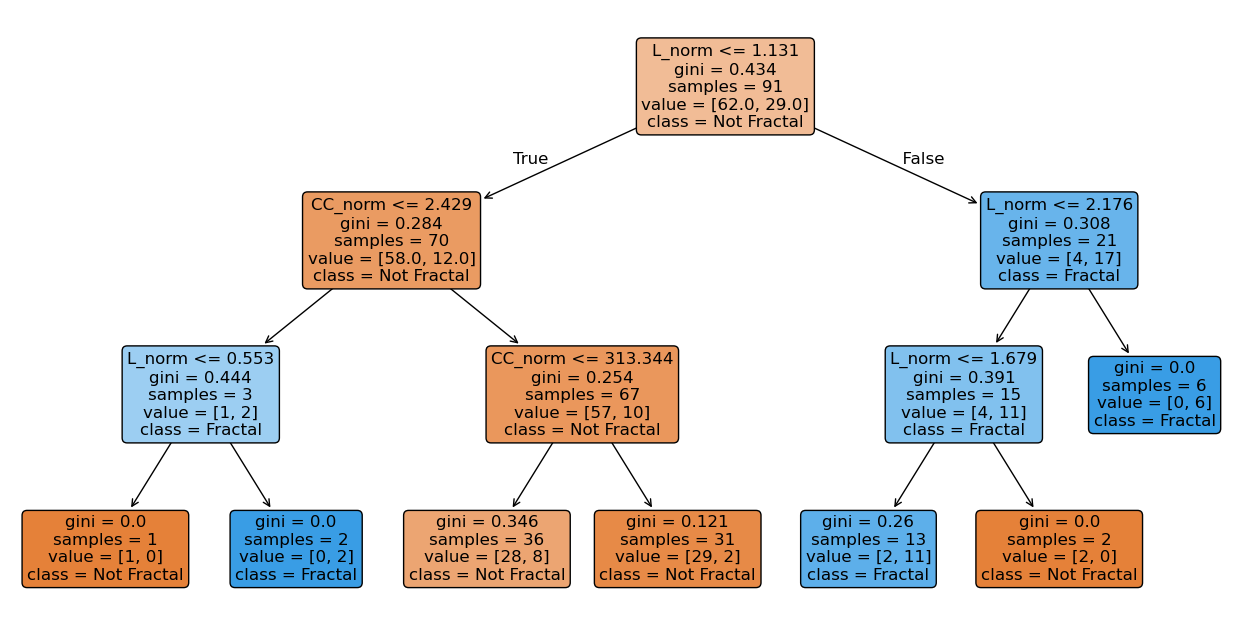

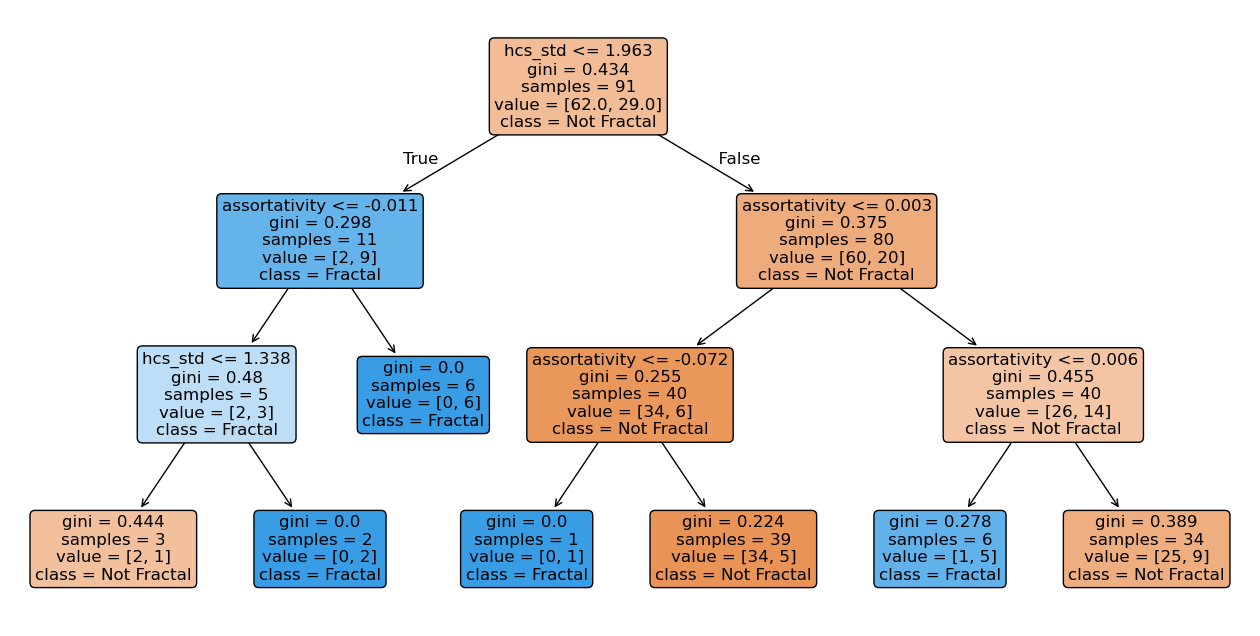

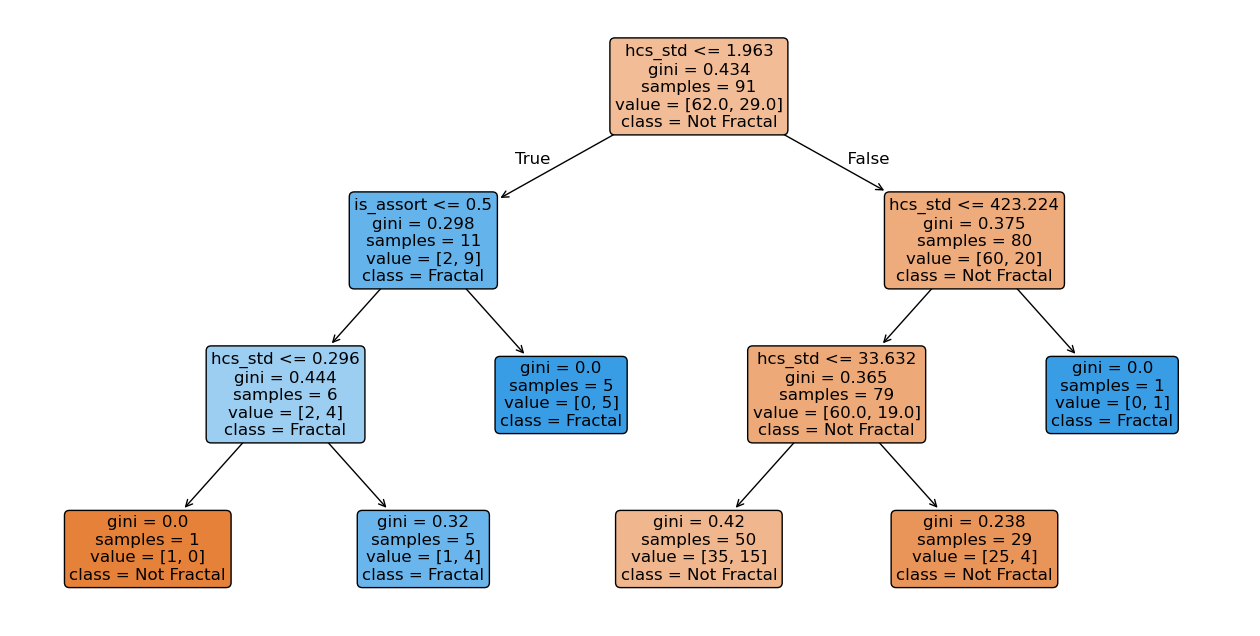

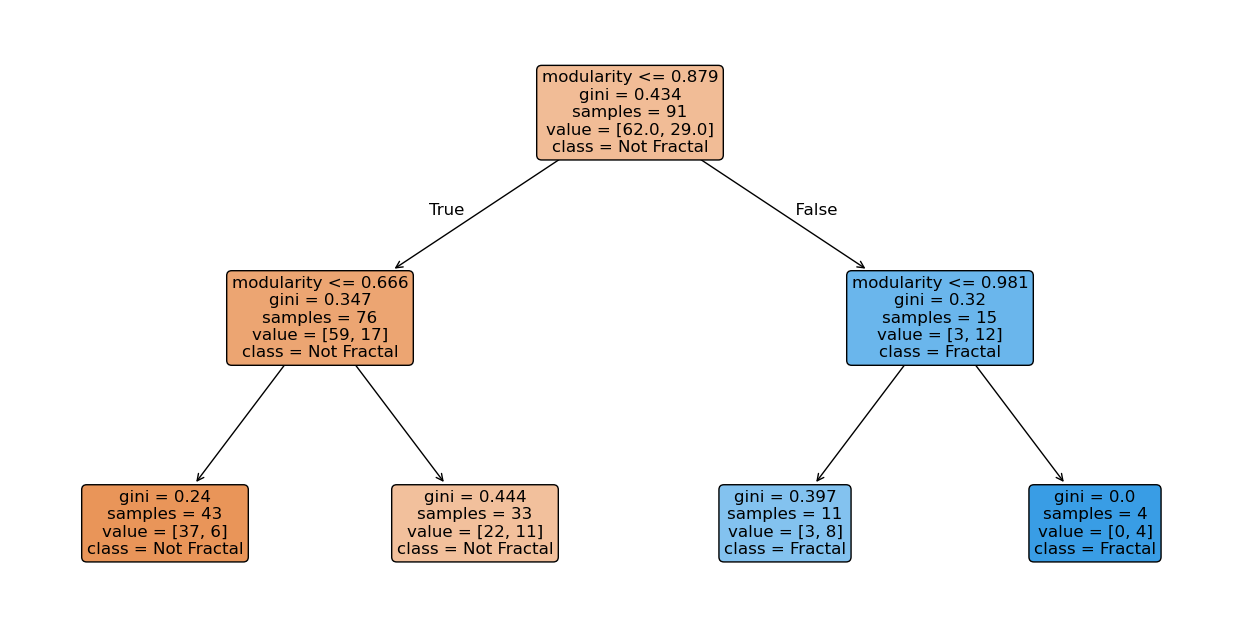

In [37]:
tree_plot(dt_classifier, feature_cols, (20, 10))
tree_plot(dt_small_world, small_world_features)
tree_plot(dt_structure, structure_features)
tree_plot(dt_structure_cat, ['hcs_std','is_assort'])
tree_plot(dt_community, community_features)

/tmp/ipykernel_1352948/747177482.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


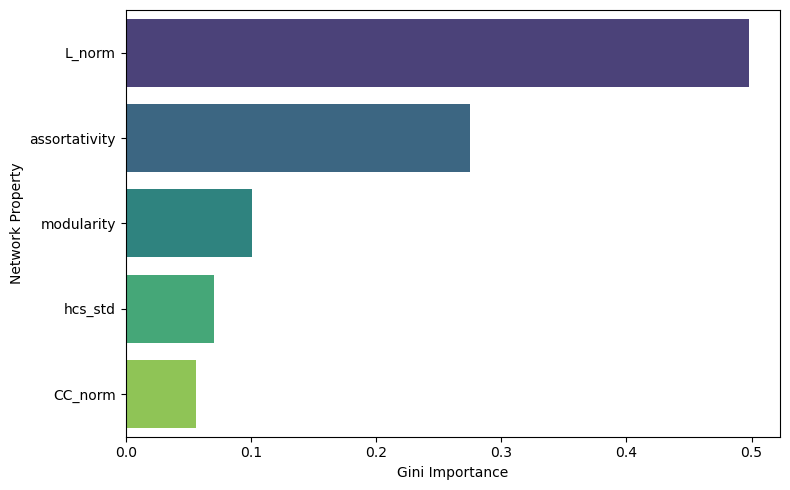

In [38]:
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': dt_classifier.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
# plt.title("Feature Importance for Predicting Fractality (Giant Component)")
plt.xlabel("Gini Importance")
plt.ylabel("Network Property")
plt.tight_layout()
plt.show()

# MST

In [39]:
add_is_fractal(to=mst_df, using_dimention=-2.3)
len(mst_df[mst_df['is_fractal']])

12

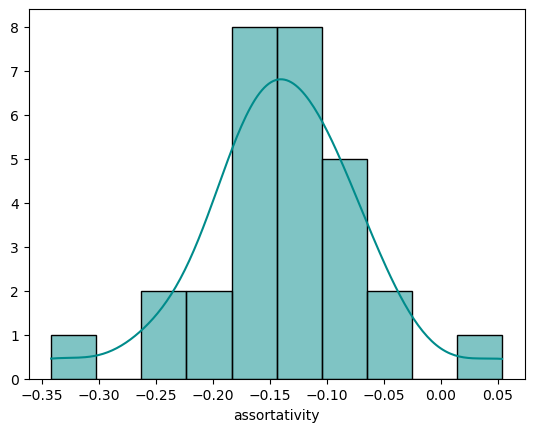

In [40]:
sns.histplot(data=mst_df, x='assortativity', kde=True, color='darkcyan')

# plt.title('Distribution of the assortativity')
# plt.yscale('log')
plt.ylabel('')
plt.xlabel('assortativity')
plt.show()

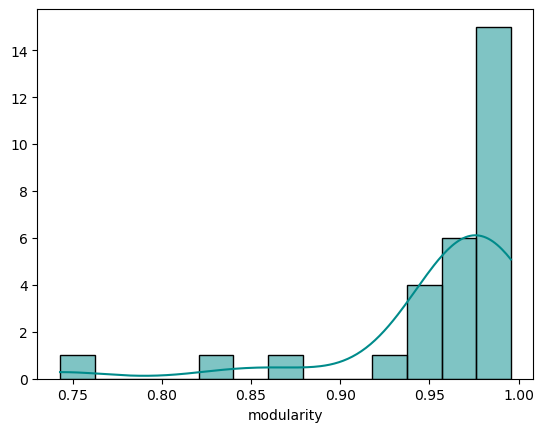

In [41]:
sns.histplot(data=mst_df, x='modularity', kde=True, color='darkcyan')

# plt.title('Distribution of the Modularity score')
# plt.yscale('log')
plt.ylabel('')
plt.xlabel('modularity')
plt.show()

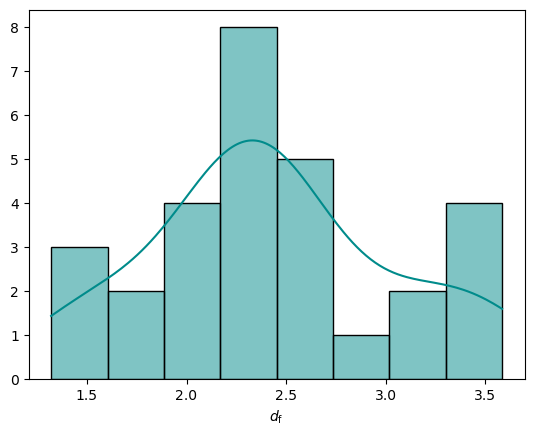

In [42]:
sns.histplot(data=mst_df.assign(pl=mst_df['fit_pl']*-1), x='pl', kde=True, color='darkcyan')

# plt.title('Distribution of the Fractality dimention')
# plt.yscale('log')
plt.ylabel('')
plt.xlabel('$d_\mathrm{f}$')
plt.show()

In [43]:
X_mst = mst_df[feature_cols]
y_mst = mst_df[target_col_clas]

mst_classifier = DecisionTreeClassifier(random_state=42, max_depth=3)
print("Training Decision Tree Classifier...")
mst_classifier.fit(X_mst, y_mst)
print("Training complete.")
print("-" * 30)

Training Decision Tree Classifier...
Training complete.
------------------------------


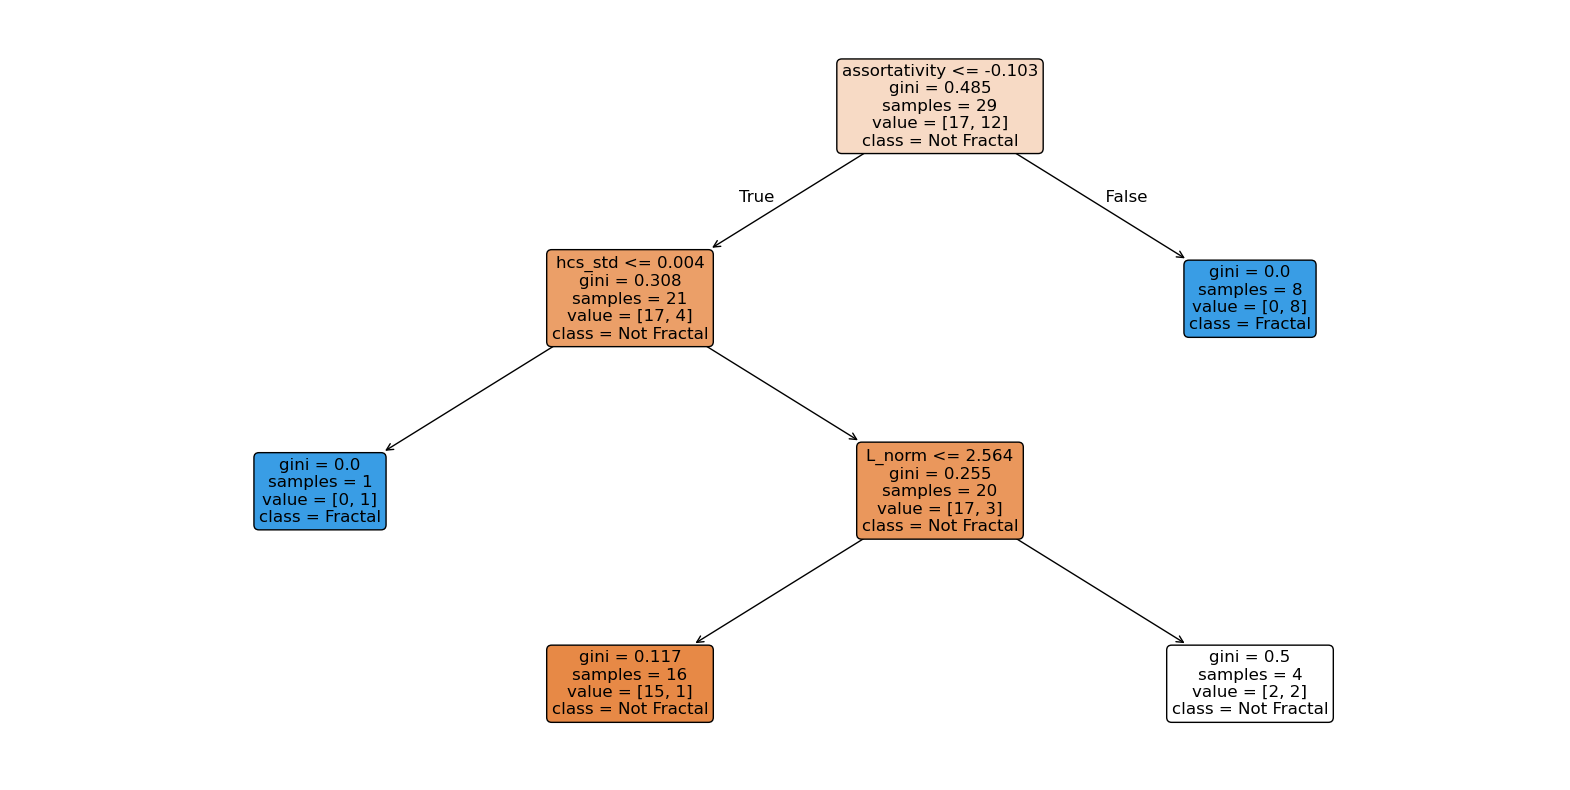

In [44]:
tree_plot(mst_classifier, feature_cols, (20,10))

/tmp/ipykernel_1352948/2763626744.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


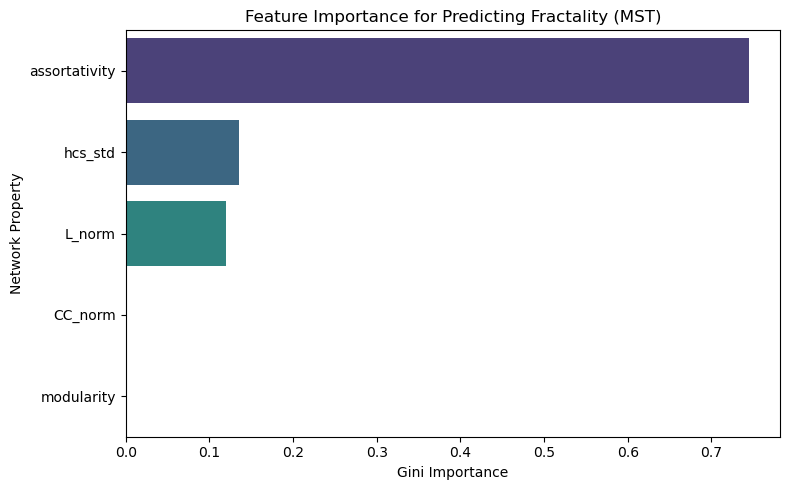

In [45]:
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': mst_classifier.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title("Feature Importance for Predicting Fractality (MST)")
plt.xlabel("Gini Importance")
plt.ylabel("Network Property")
plt.tight_layout()
plt.show()

### MST Fractality shift

In [46]:
mst_df_for_shift = mst_df.copy()
df_for_shift = df.copy()

In [47]:
add_is_fractal(to=mst_df_for_shift, using_dimention=-3)
print("After:", len(mst_df_for_shift[mst_df_for_shift['is_fractal']]))

add_is_fractal(to=df_for_shift, using_dimention=-3)
print('Before:', len(df_for_shift[df_for_shift['is_fractal']]))


After: 23
Before: 12


In [48]:
df_mst_shitf = pd.merge(
    mst_df_for_shift,
    df_for_shift[['name', 'fit_pl', 'pl_ex_ratio', 'is_fractal']],
    on='name',
    how='left',
    suffixes=('', '_before')
)

In [49]:
def display_shift_pl_fit(df):
    fig, ax_fit_pl = plt.subplots(figsize=(16, 10))
    ax_ratio = ax_fit_pl.twinx()
    df['fit_pl_before'] = df['fit_pl_before'] * -1
    df['fit_pl'] = df['fit_pl'] * -1

    x = [0, 1]
    
    for i, row in df.iterrows():
        ax_fit_pl.plot(x, [row['fit_pl_before'], row['fit_pl']], 
                color='darkcyan', alpha=0.7, marker='o', linewidth=2)
        
        ax_ratio.plot(x, [row['pl_ex_ratio_before'], row['pl_ex_ratio']], 
                color='indigo', alpha=0.7, marker='s', linewidth=2, linestyle='--')

    ax_fit_pl.set_xticks(x)
    ax_fit_pl.set_xticklabels(['Before MST', 'After MST'], fontsize=12)

    ax_fit_pl.set_ylabel('$d_\mathrm{f}$', color='darkcyan', fontsize=11)
    ax_ratio.set_ylabel('Error ratio', color='indigo', fontsize=11)
    ax_fit_pl.tick_params(axis='y', labelcolor='darkcyan')
    ax_ratio.tick_params(axis='y', labelcolor='indigo')

    legend_elements = [
        Line2D([0], [0], color='darkcyan', lw=2, marker='o', label='Shift in $d_\mathrm{f}$'),
        Line2D([0], [0], color='indigo', lw=2, marker='s', linestyle='--', label='Shift in Error ratio')
    ]
    ax_fit_pl.legend(handles=legend_elements, loc='upper right')

    # plt.title('Shifts in $d_\mathrm{f}$ and Error ratio after Extracting MST', fontsize=14)
    ax_fit_pl.grid(True, axis='x', linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

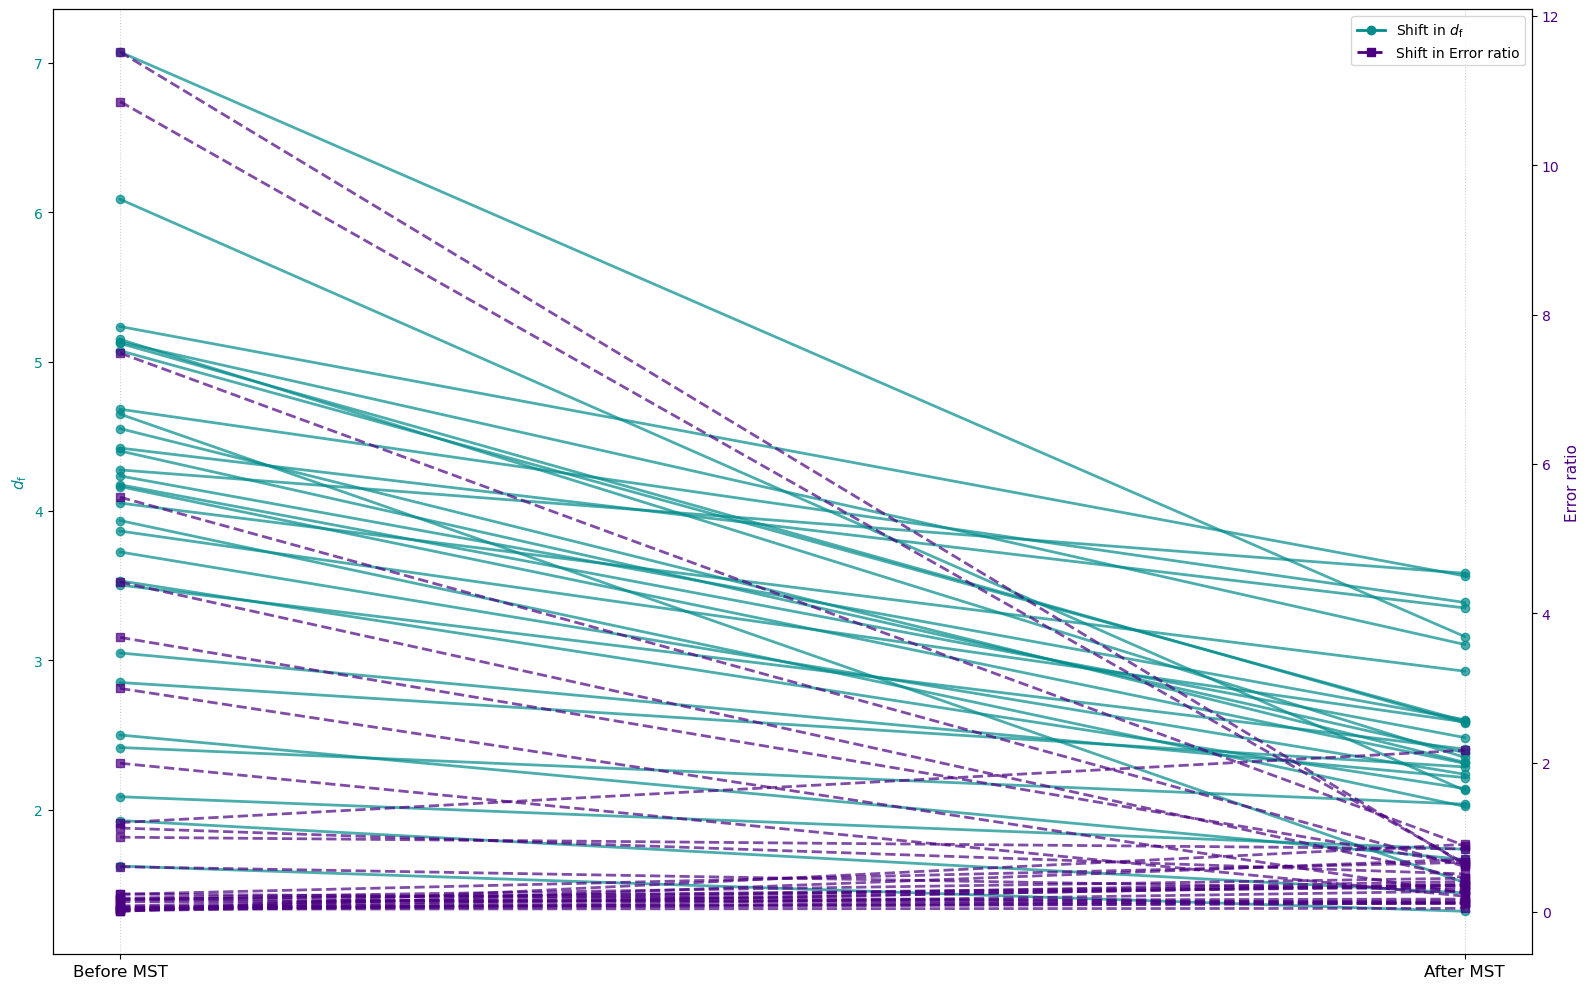

In [50]:
display_shift_pl_fit(df_mst_shitf.copy())

In [51]:
#TODO: Fix Code-hell
def is_fractal_shift(df):
    fig, ax = plt.subplots(figsize=(8, 6))

    x = [0, 1]
    np.random.seed(42)

    n_became = len(df[(df['is_fractal_before'] == False) & (df['is_fractal'] == True)])
    n_stayed_frac = len(df[(df['is_fractal_before'] == True) & (df['is_fractal'] == True)])
    n_stayed_non = len(df[(df['is_fractal_before'] == False) & (df['is_fractal'] == False)])
    n_lost = len(df[(df['is_fractal_before'] == True) & (df['is_fractal'] == False)])

    for i, row in df.iterrows():
        y0 = 1 if row['is_fractal_before'] else 0
        y1 = 1 if row['is_fractal'] else 0
        
        jitter_y0 = y0 + np.random.uniform(-0.04, 0.04)
        jitter_y1 = y1 + np.random.uniform(-0.04, 0.04)
        
        if not row['is_fractal_before'] and row['is_fractal']: # False -> True 
            color = 'darkcyan'
        elif row['is_fractal_before'] and row['is_fractal']: # True -> True
            color = 'indigo'
        elif not row['is_fractal_before'] and not row['is_fractal']: # False -> False
            color = 'gold'
        else: # True -> False
            color = 'darkorange'
            
        ax.plot(x, [jitter_y0, jitter_y1], marker='o', markersize=8, color=color, alpha=0.8, linewidth=2.5)

    bg_round_box = dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9)
    
    if n_became > 0:
        ax.text(0.4, 0.4, f"{n_became}", ha='center', va='center', fontsize=14, color='darkcyan', bbox=bg_round_box)
    
    if n_stayed_frac > 0:
        ax.text(0.5, 1.08, f"{n_stayed_frac}", ha='center', va='center', fontsize=14, color='indigo', bbox=bg_round_box)
    
    if n_stayed_non > 0:
        ax.text(0.5, -0.08, f"{n_stayed_non}", ha='center', va='center', fontsize=14, color='gold', bbox=bg_round_box)
        
    if n_lost > 0:
        ax.text(0.6, 0.4, f"{n_lost}", ha='center', va='center', fontsize=14, color='darkorange', bbox=bg_round_box)

    ax.set_xticks(x)
    ax.set_xticklabels(['Before MST', 'After MST'], fontsize=12)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Non-Fractal', 'Fractal'], fontsize=12)

    ax.set_xlim(-0.2, 1.2) 
    ax.set_ylim(-0.2, 1.2)
    # ax.set_title('Shift in Fractality After Extracting MST', fontsize=14)
    ax.grid(True, axis='both', linestyle='--', alpha=0.3)

    cat_legend = []
    if n_became > 0: 
        cat_legend.append(Line2D([0], [0], color='darkcyan', lw=2.5, marker='o', label=f'Became Fractal (n={n_became})'))
    if n_stayed_frac > 0: 
        cat_legend.append(Line2D([0], [0], color='indigo', lw=2.5, marker='o', label=f'Remained Fractal (n={n_stayed_frac})'))
    if n_stayed_non > 0: 
        cat_legend.append(Line2D([0], [0], color='gold', lw=2.5, marker='o', label=f'Remained Non-Fractal (n={n_stayed_non})'))
    if n_lost > 0: 
        cat_legend.append(Line2D([0], [0], color='darkorange', lw=2.5, marker='o', label=f'Lost Fractality (n={n_lost})'))
        
    ax.legend(handles=cat_legend, loc='center right')

    plt.tight_layout()
    plt.show()

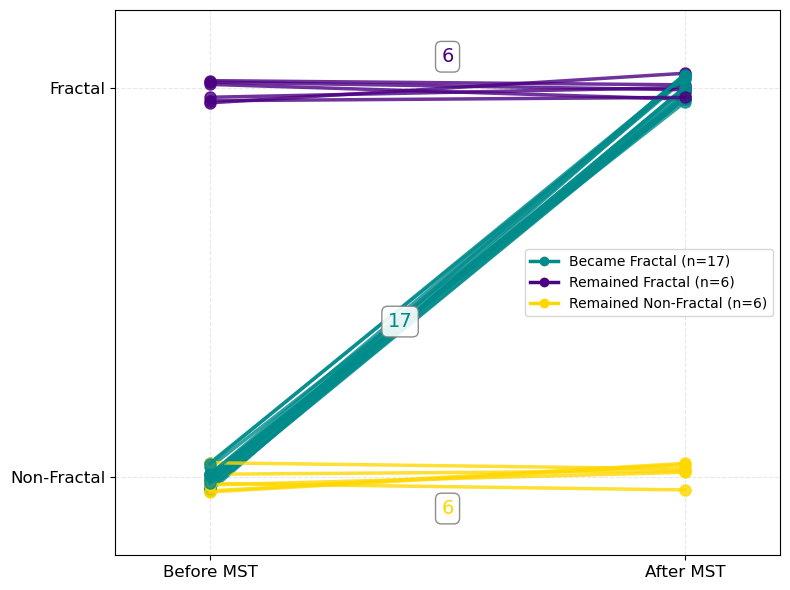

In [52]:
is_fractal_shift(df_mst_shitf.copy())

## Correlation

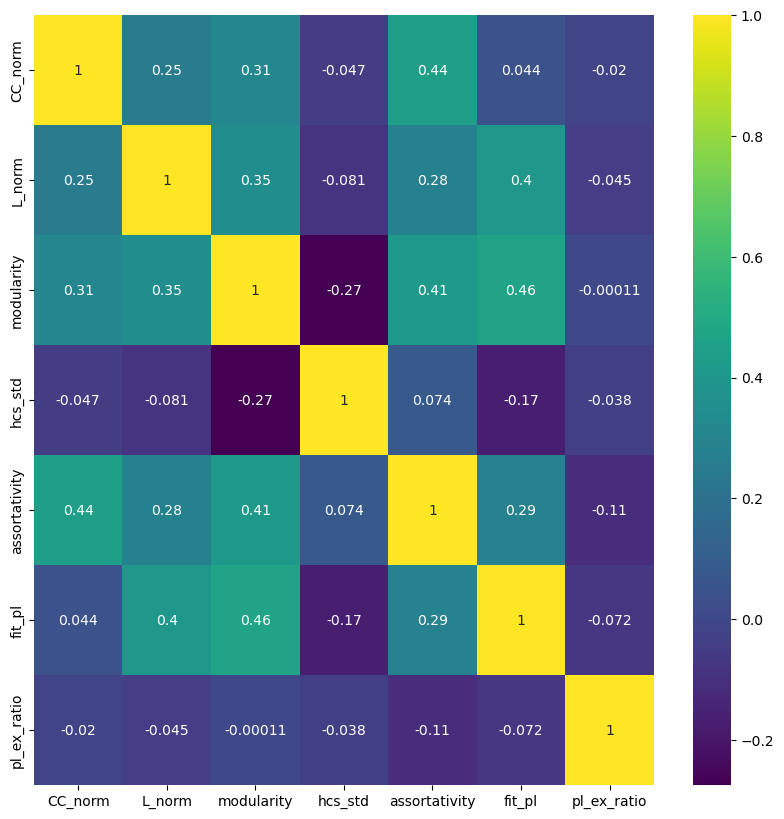

In [53]:
pearson_corr = df[[*feature_cols, 'fit_pl', 'pl_ex_ratio']].corr(method='pearson')

plt.figure(figsize=(10, 10))
sns.heatmap(pearson_corr, annot=True, cmap='viridis', )
# plt.title("Pearson Correlation")

plt.show()

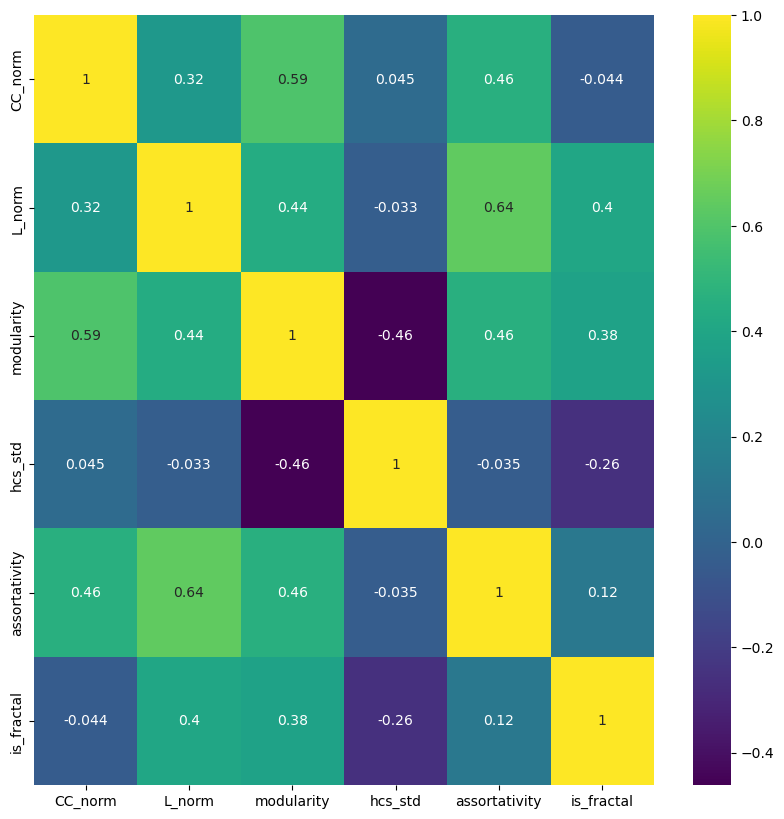

In [54]:
spearman_corr = df[[*feature_cols, 'is_fractal']].corr(method='spearman')

plt.figure(figsize=(10, 10))
sns.heatmap(spearman_corr, annot=True, cmap='viridis')
# plt.title("Spearman Correlation")
plt.show()